In [2]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine, text
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set pandas display options
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### loads `.env`
#### Setting up the `database connection`

In [3]:
load_dotenv()

pg_url = (
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
)

engine = create_engine(pg_url, pool_pre_ping=True)

with engine.begin() as conn:
    conn.execute(text("SET search_path TO mart, curated, public;"))

with engine.begin() as conn:
    print(conn.execute(text("SELECT now()")).scalar())

2025-11-25 16:36:52.644409-05:00


`38% (~212796)` fraudulent claims detected out of `558211` total claims
- `IP - 23402` (~11%) fraudulent records<br>
- `OP - 189394` (~89%) fraudulent records

#### 4.1 -  `HDBSCAN clustering` of fraudulent claims (IP & OP)

23402 IP rows; 189394 OP rows
IP: min_cluster_size=234, min_samples=117
OP: min_cluster_size=1894, min_samples=947


c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


IP clusters:
 cluster
-1      153
 0      596
 1    22653

OP clusters:
 cluster
-1     47725
 0      6775
 1     10548
 2      5020
 3      2454
 4      2185
 5      4993
 6     13321
 7      6090
 8      3870
 9     30517
 10     2039
 11    18582
 12     2388
 13     3430
 14     2652
 15     2427
 16    14242
 17    10136


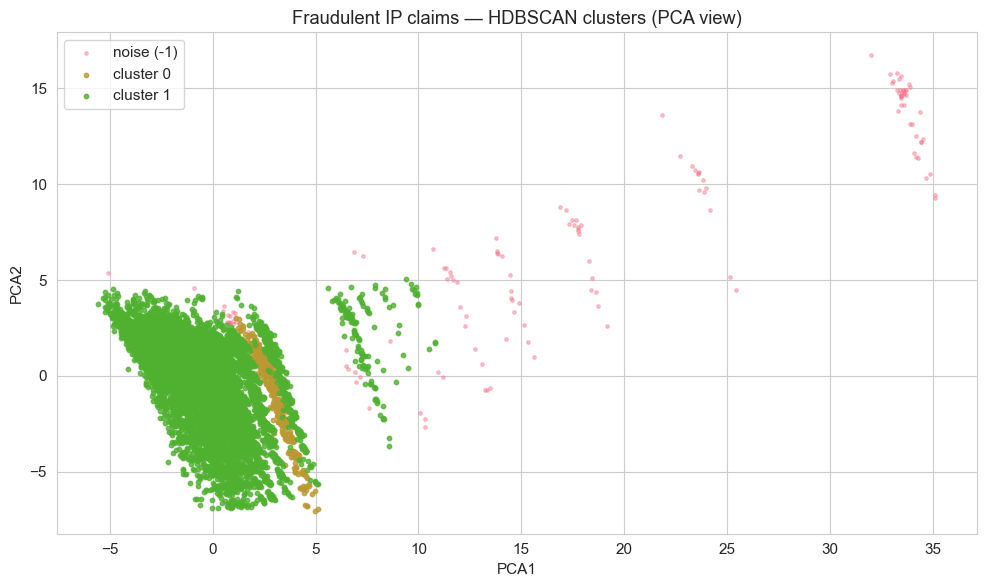

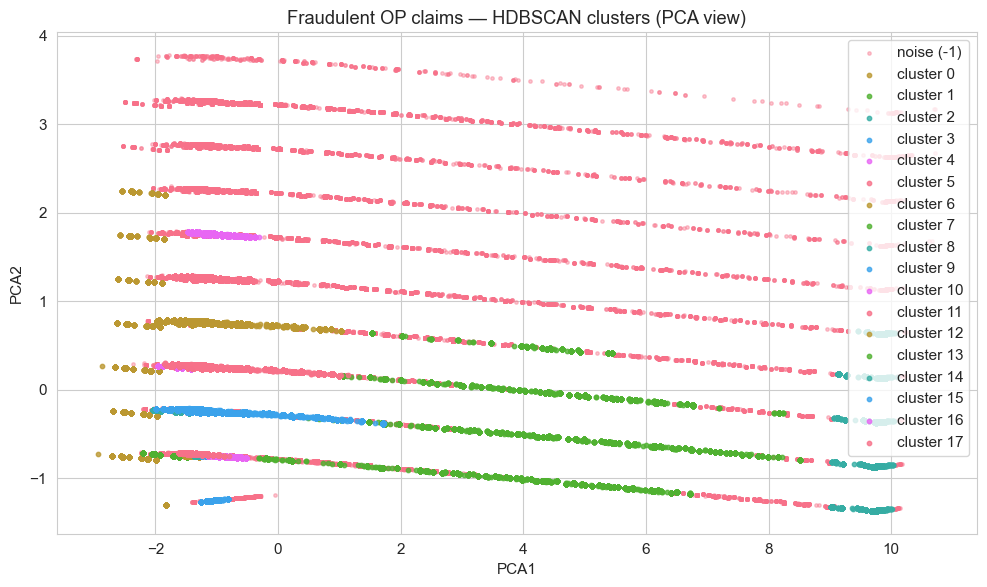

In [4]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import hdbscan

# === Load fraud-only claim tables
q_ip = "SELECT * FROM mart.fraud_claims_ip"
q_op = "SELECT * FROM mart.fraud_claims_op"
ip = pd.read_sql(q_ip, con=engine)
op = pd.read_sql(q_op, con=engine)

print(len(ip), "IP rows;", len(op), "OP rows")

# === Feature sets
ip_feats = [
    "reimb_amt",
    "deductible_paid",
    "dx_count","px_count",
    "los_days",
    "z_ip_reimb","z_ip_los",
    "dup_exact_flag","dup_near_count",
    "overcharge_z_flag","overcharge_iqr_flag",
]
op_feats = [
    "reimb_amt",
    "deductible_paid",
    "dx_count","px_count",
    "z_op_reimb",
    "dup_exact_flag","dup_near_count",
    "overcharge_z_flag","overcharge_iqr_flag",
]

def prep_claim_matrix(df, feat_cols):
    # 1) Build X; coerce numerics
    X = df[feat_cols].copy()
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    # 2) Engineer: log1p($), deductible_share
    if "reimb_amt" in X.columns:
        X["reimb_amt_log"] = np.log1p(X["reimb_amt"].clip(lower=0))
    if "deductible_paid" in X.columns and "reimb_amt" in df.columns:
        denom = df["reimb_amt"].replace(0, np.nan)
        X["deductible_share"] = (df["deductible_paid"] / denom).clip(0, 5)  # cap to tame noise

    # 3) Drop raw $ columns post-derivation
    drop_raw = [c for c in ["reimb_amt","deductible_paid"] if c in X.columns]
    X = X.drop(columns=drop_raw)

    # 4) Median impute, Robust scale (median/IQR)
    X = X.fillna(X.median(numeric_only=True))
    scaler = RobustScaler()
    Xs = scaler.fit_transform(X)

    # 5) PCA(2) for plotting only (clustering uses Xs)
    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(Xs)

    return X, Xs, X2

# --- Prepare IP & OP matrices
X_ip, Xs_ip, X2_ip = prep_claim_matrix(ip, ip_feats)
X_op, Xs_op, X2_op = prep_claim_matrix(op, op_feats)

for df_base, X_eng in [(ip, X_ip), (op, X_op)]:
    for newcol in ["reimb_amt_log","deductible_share"]:
        if newcol in X_eng.columns:
            df_base[newcol] = X_eng[newcol].values  # align by row order

# === Chose conservative HDBSCAN params
n_ip, n_op = len(ip), len(op)

mcs_ip = max(234, int(0.01 * n_ip))   # provided 23,402 -> 234
ms_ip  = max(117, int(0.5 * mcs_ip))  # ~half of min_cluster_size

mcs_op = max(1894, int(0.01 * n_op))  # provided 189,394 -> 1,894
ms_op = max(947,  int(0.5 * mcs_op))  # ~half of min_cluster_size

print(f"IP: min_cluster_size={mcs_ip}, min_samples={ms_ip}")
print(f"OP: min_cluster_size={mcs_op}, min_samples={ms_op}")

# === Fit HDBSCAN (separate models)
clusterer_ip = hdbscan.HDBSCAN(min_cluster_size=mcs_ip, min_samples=ms_ip)
clusterer_op = hdbscan.HDBSCAN(min_cluster_size=mcs_op, min_samples=ms_op)

labels_ip = clusterer_ip.fit_predict(Xs_ip)
labels_op = clusterer_op.fit_predict(Xs_op)

ip["cluster"] = labels_ip
op["cluster"] = labels_op

# === Sanity: cluster counts ( -1 = noise )
print("IP clusters:\n", ip["cluster"].value_counts(dropna=False).sort_index().to_string())
print("\nOP clusters:\n", op["cluster"].value_counts(dropna=False).sort_index().to_string())

# === Cluster profiles (medians) on the engineered feature sets
def cluster_profile(df, feat_cols):
    keep = df[df["cluster"] != -1].copy()
    if keep.empty:
        return pd.DataFrame()
    stats = keep.groupby("cluster")[feat_cols].median(numeric_only=True).reset_index()
    counts = keep["cluster"].value_counts().rename_axis("cluster").reset_index(name="n")
    prof = stats.merge(counts, on="cluster", how="left")
    return prof.sort_values("n", ascending=False)

ip_feat_profile = list(X_ip.columns)  # includes reimb_amt_log, deductible_share
op_feat_profile = list(X_op.columns)

ip_profile = cluster_profile(ip, ip_feat_profile)
op_profile = cluster_profile(op, op_feat_profile)

# === Save outputs
# ip[["claimid","provider","cluster"]].to_csv("fraud_ip_claims_with_clusters.csv", index=False)
# op[["claimid","provider","cluster"]].to_csv("fraud_op_claims_with_clusters.csv", index=False)
# ip_profile.to_csv("fraud_ip_cluster_profile.csv", index=False)
# op_profile.to_csv("fraud_op_cluster_profile.csv", index=False)

# === Simple PCA scatter
def plot_pca_scatter(X2, labels, title):
    plt.figure()
    mask_noise = (labels == -1)
    plt.scatter(X2[mask_noise,0], X2[mask_noise,1], s=6, alpha=0.4, label="noise (-1)")
    for c in np.unique(labels):
        if c == -1: 
            continue
        m = (labels == c)
        plt.scatter(X2[m,0], X2[m,1], s=10, alpha=0.8, label=f"cluster {c}")
    plt.title(title)
    plt.xlabel("PCA1"); plt.ylabel("PCA2")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()

plot_pca_scatter(X2_ip, labels_ip, "Fraudulent IP claims — HDBSCAN clusters (PCA view)")
plot_pca_scatter(X2_op, labels_op, "Fraudulent OP claims — HDBSCAN clusters (PCA view)")

`Cluster labels: -1` = noise (doesn’t fit any group). Other integers (0,1,2,…) are the `discovered fraud-type` clusters among already-fraudulent claims.